In [1]:
import networkx as nx
import jax
import jax.numpy as jnp

{0: Text(-0.31494460694026105, -0.05366721753124059, '0'),
 1: Text(0.5627194118072146, 0.6119198099946083, '1'),
 2: Text(-0.08447252305725902, -0.055230540270757064, '2'),
 3: Text(0.13845946452948163, -0.1495417772478143, '3'),
 4: Text(0.7930016114912352, -0.07296098239547927, '4'),
 5: Text(-0.15716569876886213, 0.638169057668628, '5'),
 6: Text(-0.516454540575413, 0.1890167880952313, '6'),
 7: Text(-0.3657596538923135, -0.3558814401406583, '7'),
 8: Text(0.30515384956232605, 0.3209182508088437, '8'),
 9: Text(-0.0028943608511406136, 0.3892661808110582, '9'),
 10: Text(0.09663209571074723, -0.6779488405751923, '10'),
 11: Text(0.0970019875827475, 0.0790541378509478, '11'),
 12: Text(0.4279211876775637, 0.10295807785650304, '12'),
 13: Text(0.06489813177010652, -0.4986840180376776, '13'),
 14: Text(-0.6587739270623636, -0.1494842829196884, '14'),
 15: Text(0.328435907545833, -0.3677543843526537, '15'),
 16: Text(0.42616059380937554, 0.9999999999999999, '16'),
 17: Text(-0.509896583

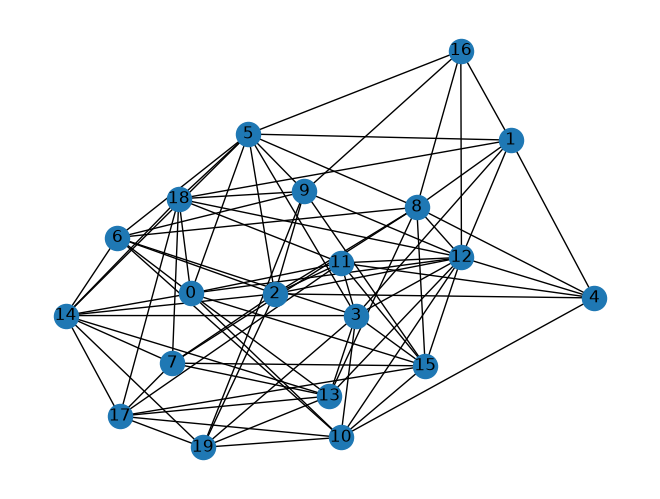

In [31]:
N = 20 #no. of nodes
p = 0.4 #ocu
G = nx.erdos_renyi_graph(N, p)
A = nx.to_numpy_array(G)
pos = nx.spring_layout(G)
labels = {node: str(node) for node in G.nodes()}
nx.draw(G, pos)
nx.draw_networkx_labels(G, pos, labels)

In [ ]:
from bp_error.perc_func import perc_message_passing


connections = {}
node_weights = {}

for i in range(N):
    for j in range(N):
        if A[i][j] == 1 and A[j][i] == 1:
            connections[f'{i}, {j}'] = 0.5
            connections[f'{j}, {i}'] = 0.5

for i in range(0, 60):

    for key, values in connections.items():
        row, col = key.split(', ')
        failure = jnp.array([0, 0])
        failure = perc_message_passing(connections, A, int(row), int(col), 0.4, N)
        connections[f'{col}, {row}'] = float(failure[0]) #0.125 2->0
        connections[f'{row}, {col}'] = float(failure[1]) #0.5 0->2

for i in range(0, N):
    temp = 1
    for j in range(0, N):
        if A[i][j] == 1:
            temp = temp * connections[f'{i}, {j}']
    node_weights[f'{i}'] = 1 - temp

node_colors = [node_weights[str(n)] for n in G.nodes()]
nx.draw(G, pos)
nx.draw_networkx_labels(G, pos, labels)
nx.draw_networkx_nodes(G, pos, node_color=node_colors)

KeyError: 0